# 06 — XGBoost

This notebook builds the main nonlinear challenger for the RDU hourly temperature forecasting project.

The central idea is **GFS residual correction**:

\[
	ext{residual} = T_{actual} - T_{GFS}
\]

XGBoost learns when GFS tends to be too warm or too cold, using forecast horizon, time of day, humidity, pressure, wind, cloud cover, precipitation, and recent RDU conditions.

We also include direct-temperature XGBoost candidates so that residual correction has to earn its place empirically.

## Locked evaluation protocol

We keep exactly the same chronology as the linear-regression notebook:

- **2021–2023:** training
- **2024:** validation / model selection
- **2025:** untouched historical test
- **2026:** final assignment forecast

All feature-set and hyperparameter choices are made using **2024 only**.  
Only after the winning XGBoost specification is frozen do we evaluate it once on 2025.

## Inputs

- `data/processed/modeling_historical.csv`
- `data/processed/modeling_future.csv`
- `data/processed/modeling_feature_manifest.json`

Optional comparison inputs if notebook 05 has already been run:

- `data/processed/linear_regression_validation_results.csv`
- `data/processed/linear_regression_test_results.csv`
- `data/processed/linear_regression_2026_predictions.csv`

## Outputs

- `data/processed/xgboost_validation_results.csv`
- `data/processed/xgboost_test_results.csv`
- `data/processed/xgboost_2025_test_predictions.csv`
- `data/processed/xgboost_2026_predictions.csv`
- `data/processed/xgboost_feature_importance.csv`
- `data/processed/xgboost_selected_config.json`

In [2]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

try:
    import xgboost as xgb
    from xgboost import XGBRegressor
except ImportError as e:
    raise ImportError(
        "xgboost is not installed in this Python environment. "
        "Install it in your project environment (for example: "
        "`pip install xgboost`) and rerun this notebook."
    ) from e

print("xgboost version:", xgb.__version__)

xgboost version: 3.2.0


## 1. Locate project files

In [3]:
def find_project_root():
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd().parent.parent,
    ]

    for candidate in candidates:
        if (
            candidate / "data" / "processed" / "modeling_historical.csv"
        ).exists():
            return candidate.resolve()

    raise FileNotFoundError(
        "Could not find data/processed/modeling_historical.csv. "
        "Run 04_eda_and_build_modeling_data.ipynb first."
    )


PROJECT_ROOT = find_project_root()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

HISTORICAL_PATH = PROCESSED_DIR / "modeling_historical.csv"
FUTURE_PATH = PROCESSED_DIR / "modeling_future.csv"
MANIFEST_PATH = PROCESSED_DIR / "modeling_feature_manifest.json"

LINEAR_VAL_PATH = (
    PROCESSED_DIR / "linear_regression_validation_results.csv"
)
LINEAR_TEST_PATH = (
    PROCESSED_DIR / "linear_regression_test_results.csv"
)
LINEAR_2026_PATH = (
    PROCESSED_DIR / "linear_regression_2026_predictions.csv"
)

print("Project root:", PROJECT_ROOT)
print("Processed directory:", PROCESSED_DIR)

Project root: /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU
Processed directory: /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/data/processed


In [4]:
historical = pd.read_csv(
    HISTORICAL_PATH,
    parse_dates=[
        "gfs_init_utc",
        "valid_time_utc",
        "valid_time_local",
        "simulated_cutoff_utc",
    ],
)

future = pd.read_csv(
    FUTURE_PATH,
    parse_dates=[
        "gfs_init_utc",
        "valid_time_utc",
        "valid_time_local",
        "simulated_cutoff_utc",
    ],
)

with open(MANIFEST_PATH, "r", encoding="utf-8") as f:
    manifest = json.load(f)

TARGET = manifest["target"]
ALL_FEATURES = manifest["model_features"]

print("Historical shape:", historical.shape)
print("Future shape:", future.shape)
print("Target:", TARGET)
print("Available features:", len(ALL_FEATURES))

Historical shape: (13237, 44)
Future shape: (336, 43)
Target: actual_temp_f
Available features: 32


## 2. Locked train / validation / test splits

In [5]:
train = historical[
    historical["split"] == "train"
].copy()

validation = historical[
    historical["split"] == "validation"
].copy()

test = historical[
    historical["split"] == "test"
].copy()

print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)
print("Future:", future.shape)

assert set(historical["split"].unique()) == {
    "train",
    "validation",
    "test",
}

assert len(future) == 336
assert future["split"].eq("forecast_2026").all()

assert TARGET not in future.columns
assert historical[TARGET].isna().sum() == 0
assert historical[ALL_FEATURES].isna().sum().sum() == 0
assert future[ALL_FEATURES].isna().sum().sum() == 0

print("PASS: split and missingness checks succeeded.")

Train: (8064, 44)
Validation: (2688, 44)
Test: (2485, 44)
Future: (336, 43)
PASS: split and missingness checks succeeded.


## 3. Metrics and baselines

In [6]:
def metrics_from_arrays(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    error = y_pred - y_true

    return {
        "n": len(y_true),
        "RMSE_F": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred,
            )
        ),
        "MAE_F": mean_absolute_error(
            y_true,
            y_pred,
        ),
        "Bias_F": error.mean(),
        "R2": r2_score(
            y_true,
            y_pred,
        ),
    }


def per_run_metrics(
    frame,
    prediction_column,
):
    rows = []

    for init_time, group in frame.groupby(
        "gfs_init_utc",
        sort=True,
    ):
        metrics = metrics_from_arrays(
            group[TARGET],
            group[prediction_column],
        )

        rows.append({
            "gfs_init_utc": init_time,
            **metrics,
        })

    return pd.DataFrame(rows)


def summarize_model(
    frame,
    prediction_column,
):
    pooled = metrics_from_arrays(
        frame[TARGET],
        frame[prediction_column],
    )

    run_metrics = per_run_metrics(
        frame,
        prediction_column,
    )

    return {
        **pooled,
        "mean_run_RMSE_F": run_metrics["RMSE_F"].mean(),
        "median_run_RMSE_F": run_metrics["RMSE_F"].median(),
        "worst_run_RMSE_F": run_metrics["RMSE_F"].max(),
    }

In [7]:
validation_baseline = validation.copy()
validation_baseline["pred_raw_gfs"] = (
    validation_baseline["gfs_temp_f"]
)

raw_validation_summary = summarize_model(
    validation_baseline,
    "pred_raw_gfs",
)

print("Raw GFS — 2024 validation")
for key, value in raw_validation_summary.items():
    if key != "n":
        print(f"  {key}: {value:.4f}")

Raw GFS — 2024 validation
  RMSE_F: 6.3628
  MAE_F: 4.9068
  Bias_F: -1.4968
  R2: 0.3446
  mean_run_RMSE_F: 6.2290
  median_run_RMSE_F: 6.1219
  worst_run_RMSE_F: 8.4388


## 4. Candidate feature sets

XGBoost can handle redundancy much better than ordinary least squares, but we still compare feature sets rather than assuming "all features" is best.

### Core weather set
GFS atmospheric state + forecast horizon + calendar.

### Full set
Core weather plus recent RDU observations available before the forecast window.

### Compact residual set
A smaller postprocessing model focused on likely drivers of GFS error.

This lets us learn whether the recent-observation features genuinely help or simply add noise.

In [8]:
CORE_WEATHER_FEATURES = [
    "gfs_temp_f",
    "gfs_relative_humidity_pct",
    "gfs_dewpoint_f",
    "gfs_dewpoint_depression_f",
    "gfs_u10_mps",
    "gfs_v10_mps",
    "gfs_wind_speed_mph",
    "gfs_wind_dir_sin",
    "gfs_wind_dir_cos",
    "gfs_mslp_hpa",
    "gfs_total_cloud_cover_pct",
    "gfs_precip_rate_mm_hr",
    "forecast_hour",
    "hours_into_target",
    "target_day",
    "is_native_gfs_time",
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos",
]

FULL_FEATURES = ALL_FEATURES.copy()

COMPACT_RESIDUAL_FEATURES = [
    "gfs_temp_f",
    "forecast_hour",
    "target_day",
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos",
    "gfs_relative_humidity_pct",
    "gfs_dewpoint_depression_f",
    "gfs_u10_mps",
    "gfs_v10_mps",
    "gfs_mslp_hpa",
    "gfs_total_cloud_cover_pct",
    "gfs_precip_rate_mm_hr",
    "recent_actual_temp_f",
    "recent_24h_mean_f",
    "recent_24h_change_f",
    "recent_24h_range_f",
    "gfs_temp_minus_recent_actual_f",
]

FEATURE_SETS = {
    "core_weather": CORE_WEATHER_FEATURES,
    "full": FULL_FEATURES,
    "compact_residual": COMPACT_RESIDUAL_FEATURES,
}

for name, features in FEATURE_SETS.items():
    missing = sorted(
        set(features)
        - set(ALL_FEATURES)
    )

    if missing:
        raise KeyError(
            f"{name} has unavailable features: {missing}"
        )

    print(
        f"{name}: {len(features)} features"
    )

core_weather: 20 features
full: 32 features
compact_residual: 19 features


## 5. Compact hyperparameter search

This is intentionally a **small, predeclared search** so we do not overfit our modeling process to one validation year.

The grid explores:

- shallow vs moderately deep trees
- conservative vs faster learning rates
- stronger vs weaker regularization
- full vs partial row/column sampling

We compare both:
- **residual correction**
- **direct temperature prediction**

Primary selection metric: **2024 pooled RMSE**  
Tie-breaker: **2024 mean forecast-run RMSE**

In [9]:
PARAMETER_SETS = [
    {
        "param_name": "shallow_conservative",
        "n_estimators": 700,
        "learning_rate": 0.03,
        "max_depth": 2,
        "min_child_weight": 8,
        "subsample": 0.90,
        "colsample_bytree": 0.90,
        "reg_alpha": 0.10,
        "reg_lambda": 8.0,
    },
    {
        "param_name": "shallow_balanced",
        "n_estimators": 500,
        "learning_rate": 0.05,
        "max_depth": 2,
        "min_child_weight": 5,
        "subsample": 1.00,
        "colsample_bytree": 1.00,
        "reg_alpha": 0.00,
        "reg_lambda": 5.0,
    },
    {
        "param_name": "medium_balanced",
        "n_estimators": 500,
        "learning_rate": 0.05,
        "max_depth": 3,
        "min_child_weight": 5,
        "subsample": 0.90,
        "colsample_bytree": 0.90,
        "reg_alpha": 0.10,
        "reg_lambda": 8.0,
    },
    {
        "param_name": "medium_regularized",
        "n_estimators": 700,
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_child_weight": 10,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "reg_alpha": 0.25,
        "reg_lambda": 12.0,
    },
    {
        "param_name": "deeper_regularized",
        "n_estimators": 350,
        "learning_rate": 0.05,
        "max_depth": 4,
        "min_child_weight": 10,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "reg_alpha": 0.25,
        "reg_lambda": 12.0,
    },
]

SEARCH_SPECS = []

# Residual models get the most attention because this is the primary idea.
for feature_set_name in [
    "compact_residual",
    "core_weather",
    "full",
]:
    for params in PARAMETER_SETS:
        SEARCH_SPECS.append({
            "feature_set": feature_set_name,
            "target_mode": "residual",
            **params,
        })

# Direct prediction is included as a smaller challenger set.
for params in [
    PARAMETER_SETS[0],
    PARAMETER_SETS[2],
    PARAMETER_SETS[3],
]:
    SEARCH_SPECS.append({
        "feature_set": "full",
        "target_mode": "direct",
        **params,
    })

print("Candidate models:", len(SEARCH_SPECS))

Candidate models: 18


## 6. XGBoost training helpers

In [10]:
RANDOM_STATE = 42


def make_xgb_regressor(spec):
    return XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,

        n_estimators=spec["n_estimators"],
        learning_rate=spec["learning_rate"],
        max_depth=spec["max_depth"],
        min_child_weight=spec["min_child_weight"],
        subsample=spec["subsample"],
        colsample_bytree=spec["colsample_bytree"],
        reg_alpha=spec["reg_alpha"],
        reg_lambda=spec["reg_lambda"],
    )


def training_target(frame, target_mode):
    if target_mode == "direct":
        return frame[TARGET]

    if target_mode == "residual":
        return (
            frame[TARGET]
            - frame["gfs_temp_f"]
        )

    raise ValueError(
        f"Unknown target mode: {target_mode}"
    )


def predictions_from_model(
    model,
    frame,
    features,
    target_mode,
):
    model_output = model.predict(
        frame[features]
    )

    if target_mode == "direct":
        return model_output

    if target_mode == "residual":
        return (
            frame["gfs_temp_f"].to_numpy()
            + model_output
        )

    raise ValueError(
        f"Unknown target mode: {target_mode}"
    )


def fit_xgb(
    train_frame,
    features,
    spec,
):
    model = make_xgb_regressor(spec)

    y_train = training_target(
        train_frame,
        spec["target_mode"],
    )

    model.fit(
        train_frame[features],
        y_train,
        verbose=False,
    )

    return model

## 7. Run the 2024 validation search

In [11]:
validation_search_rows = []
candidate_models = {}

for i, spec in enumerate(
    SEARCH_SPECS,
    start=1,
):
    feature_set_name = spec[
        "feature_set"
    ]

    features = FEATURE_SETS[
        feature_set_name
    ]

    candidate_name = (
        f"{spec['target_mode']}"
        f"__{feature_set_name}"
        f"__{spec['param_name']}"
    )

    print(
        f"[{i:02d}/{len(SEARCH_SPECS):02d}] "
        f"{candidate_name}"
    )

    model = fit_xgb(
        train_frame=train,
        features=features,
        spec=spec,
    )

    predictions = predictions_from_model(
        model=model,
        frame=validation,
        features=features,
        target_mode=spec["target_mode"],
    )

    evaluation_frame = validation.copy()
    evaluation_frame[
        "candidate_prediction"
    ] = predictions

    summary = summarize_model(
        evaluation_frame,
        "candidate_prediction",
    )

    validation_search_rows.append({
        "candidate": candidate_name,
        "target_mode": spec["target_mode"],
        "feature_set": feature_set_name,
        "n_features": len(features),
        "param_name": spec["param_name"],
        "n_estimators": spec["n_estimators"],
        "learning_rate": spec["learning_rate"],
        "max_depth": spec["max_depth"],
        "min_child_weight": spec["min_child_weight"],
        "subsample": spec["subsample"],
        "colsample_bytree": spec["colsample_bytree"],
        "reg_alpha": spec["reg_alpha"],
        "reg_lambda": spec["reg_lambda"],
        **summary,
    })

    candidate_models[
        candidate_name
    ] = model


validation_results = (
    pd.DataFrame(
        validation_search_rows
    )
    .sort_values(
        [
            "RMSE_F",
            "mean_run_RMSE_F",
            "MAE_F",
        ]
    )
    .reset_index(drop=True)
)

display(
    validation_results.round(4)
)

[01/18] residual__compact_residual__shallow_conservative
[02/18] residual__compact_residual__shallow_balanced
[03/18] residual__compact_residual__medium_balanced
[04/18] residual__compact_residual__medium_regularized
[05/18] residual__compact_residual__deeper_regularized
[06/18] residual__core_weather__shallow_conservative
[07/18] residual__core_weather__shallow_balanced
[08/18] residual__core_weather__medium_balanced
[09/18] residual__core_weather__medium_regularized
[10/18] residual__core_weather__deeper_regularized
[11/18] residual__full__shallow_conservative
[12/18] residual__full__shallow_balanced
[13/18] residual__full__medium_balanced
[14/18] residual__full__medium_regularized
[15/18] residual__full__deeper_regularized
[16/18] direct__full__shallow_conservative
[17/18] direct__full__medium_balanced
[18/18] direct__full__medium_regularized


,candidate,target_mode,feature_set,n_features,param_name,n_estimators,learning_rate,max_depth,min_child_weight,subsample,...,reg_alpha,reg_lambda,n,RMSE_F,MAE_F,Bias_F,R2,mean_run_RMSE_F,median_run_RMSE_F,worst_run_RMSE_F
0,residual__compact_residual__medium_regularized,residual,compact_residual,19,medium_regularized,700,0.03,3,10,0.85,...,0.25,12.0,2688,5.2623,4.1035,-0.1865,0.5517,5.1192,4.4313,7.3920
1,residual__compact_residual__shallow_conservative,residual,compact_residual,19,shallow_conservative,700,0.03,2,8,0.90,...,0.10,8.0,2688,5.2862,4.1139,-0.2067,0.5476,5.1168,4.4191,7.4059
2,residual__compact_residual__medium_balanced,residual,compact_residual,19,medium_balanced,500,0.05,3,5,0.90,...,0.10,8.0,2688,5.2963,4.1112,-0.1350,0.5459,5.1496,4.5772,7.4842
3,residual__compact_residual__deeper_regularized,residual,compact_residual,19,deeper_regularized,350,0.05,4,10,0.85,...,0.25,12.0,2688,5.3086,4.1046,-0.0507,0.5438,5.1660,4.5709,7.5462
4,residual__compact_residual__shallow_balanced,residual,compact_residual,19,shallow_balanced,500,0.05,2,5,1.00,...,0.00,5.0,2688,5.3154,4.1296,-0.1495,0.5426,5.1300,4.4209,7.6332
5,residual__full__medium_regularized,residual,full,32,medium_regularized,700,0.03,3,10,0.85,...,0.25,12.0,2688,5.3521,4.1487,-0.5870,0.5363,5.1661,4.4367,7.9488
6,residual__full__shallow_conservative,residual,full,32,shallow_conservative,700,0.03,2,8,0.90,...,0.10,8.0,2688,5.3524,4.1433,-0.5592,0.5362,5.1420,4.4661,7.9807
7,residual__full__deeper_regularized,residual,full,32,deeper_regularized,350,0.05,4,10,0.85,...,0.25,12.0,2688,5.3678,4.1719,-0.6098,0.5336,5.2086,4.5924,7.8521
8,residual__full__medium_balanced,residual,full,32,medium_balanced,500,0.05,3,5,0.90,...,0.10,8.0,2688,5.3808,4.1653,-0.4919,0.5313,5.1984,4.5057,8.0102
9,residual__full__shallow_balanced,residual,full,32,shallow_balanced,500,0.05,2,5,1.00,...,0.00,5.0,2688,5.3918,4.1759,-0.5254,0.5294,5.1750,4.4755,8.1820


## 8. Compare XGBoost against raw GFS and linear regression

In [12]:
comparison_rows = [
    {
        "model": "Raw_GFS",
        "RMSE_F": raw_validation_summary["RMSE_F"],
        "MAE_F": raw_validation_summary["MAE_F"],
        "Bias_F": raw_validation_summary["Bias_F"],
        "R2": raw_validation_summary["R2"],
        "mean_run_RMSE_F": raw_validation_summary[
            "mean_run_RMSE_F"
        ],
    }
]

if LINEAR_VAL_PATH.exists():
    linear_val = pd.read_csv(
        LINEAR_VAL_PATH
    )

    # Keep the best non-raw linear candidate.
    linear_candidates = linear_val[
        linear_val["model"] != "Raw_GFS"
    ].copy()

    if len(linear_candidates):
        best_linear_val = (
            linear_candidates
            .sort_values("RMSE_F")
            .iloc[0]
        )

        comparison_rows.append({
            "model": (
                "Best_Linear__"
                + str(best_linear_val["model"])
            ),
            "RMSE_F": best_linear_val["RMSE_F"],
            "MAE_F": best_linear_val["MAE_F"],
            "Bias_F": best_linear_val["Bias_F"],
            "R2": best_linear_val["R2"],
            "mean_run_RMSE_F": best_linear_val[
                "mean_run_RMSE_F"
            ],
        })

best_xgb_val = validation_results.iloc[0]

comparison_rows.append({
    "model": (
        "Best_XGBoost__"
        + best_xgb_val["candidate"]
    ),
    "RMSE_F": best_xgb_val["RMSE_F"],
    "MAE_F": best_xgb_val["MAE_F"],
    "Bias_F": best_xgb_val["Bias_F"],
    "R2": best_xgb_val["R2"],
    "mean_run_RMSE_F": best_xgb_val[
        "mean_run_RMSE_F"
    ],
})

validation_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values("RMSE_F")
    .reset_index(drop=True)
)

display(
    validation_comparison.round(4)
)

,model,RMSE_F,MAE_F,Bias_F,R2,mean_run_RMSE_F
0,Best_XGBoost__residual__compact_residual__medi...,5.2623,4.1035,-0.1865,0.5517,5.1192
1,Best_Linear__OLS_GFS_only,5.3511,4.0578,-0.3052,0.5365,5.2258
2,Raw_GFS,6.3628,4.9068,-1.4968,0.3446,6.2290


In [13]:
VAL_RESULTS_PATH = (
    PROCESSED_DIR
    / "xgboost_validation_results.csv"
)

validation_results.to_csv(
    VAL_RESULTS_PATH,
    index=False,
)

print("Saved:", VAL_RESULTS_PATH)

Saved: /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/data/processed/xgboost_validation_results.csv


## 9. Freeze the winning XGBoost specification

The winning specification is chosen using **2024 validation RMSE only**.

After this point:

- do not change its feature set based on 2025
- do not change its hyperparameters based on 2025
- do not add/remove features because of 2025

That preserves 2025 as a real historical test.

In [14]:
WINNER = validation_results.iloc[0].to_dict()

FINAL_CANDIDATE_NAME = WINNER[
    "candidate"
]

FINAL_FEATURE_SET_NAME = WINNER[
    "feature_set"
]

FINAL_FEATURES = FEATURE_SETS[
    FINAL_FEATURE_SET_NAME
]

FINAL_SPEC = {
    "feature_set": FINAL_FEATURE_SET_NAME,
    "target_mode": WINNER["target_mode"],
    "param_name": WINNER["param_name"],
    "n_estimators": int(
        WINNER["n_estimators"]
    ),
    "learning_rate": float(
        WINNER["learning_rate"]
    ),
    "max_depth": int(
        WINNER["max_depth"]
    ),
    "min_child_weight": float(
        WINNER["min_child_weight"]
    ),
    "subsample": float(
        WINNER["subsample"]
    ),
    "colsample_bytree": float(
        WINNER["colsample_bytree"]
    ),
    "reg_alpha": float(
        WINNER["reg_alpha"]
    ),
    "reg_lambda": float(
        WINNER["reg_lambda"]
    ),
}

print("Frozen candidate:", FINAL_CANDIDATE_NAME)
print("Target mode:", FINAL_SPEC["target_mode"])
print("Feature set:", FINAL_FEATURE_SET_NAME)
print("Features:", len(FINAL_FEATURES))
print("Validation RMSE:", WINNER["RMSE_F"])
print("Validation MAE:", WINNER["MAE_F"])
print("Validation bias:", WINNER["Bias_F"])

print("\nHyperparameters:")
for key, value in FINAL_SPEC.items():
    if key not in {
        "feature_set",
        "target_mode",
        "param_name",
    }:
        print(f"  {key}: {value}")

Frozen candidate: residual__compact_residual__medium_regularized
Target mode: residual
Feature set: compact_residual
Features: 19
Validation RMSE: 5.262284311804667
Validation MAE: 4.103479186762996
Validation bias: -0.18647101009158074

Hyperparameters:
  n_estimators: 700
  learning_rate: 0.03
  max_depth: 3
  min_child_weight: 10.0
  subsample: 0.85
  colsample_bytree: 0.85
  reg_alpha: 0.25
  reg_lambda: 12.0


In [15]:
SELECTED_CONFIG_PATH = (
    PROCESSED_DIR
    / "xgboost_selected_config.json"
)

selected_config_for_disk = {
    "candidate": FINAL_CANDIDATE_NAME,
    "target_mode": FINAL_SPEC["target_mode"],
    "feature_set": FINAL_FEATURE_SET_NAME,
    "features": FINAL_FEATURES,
    "hyperparameters": {
        key: value
        for key, value in FINAL_SPEC.items()
        if key not in {
            "feature_set",
            "target_mode",
            "param_name",
        }
    },
    "validation_metrics": {
        "RMSE_F": float(WINNER["RMSE_F"]),
        "MAE_F": float(WINNER["MAE_F"]),
        "Bias_F": float(WINNER["Bias_F"]),
        "R2": float(WINNER["R2"]),
        "mean_run_RMSE_F": float(
            WINNER["mean_run_RMSE_F"]
        ),
    },
}

with open(
    SELECTED_CONFIG_PATH,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        selected_config_for_disk,
        f,
        indent=2,
    )

print(
    "Saved:",
    SELECTED_CONFIG_PATH,
)

Saved: /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/data/processed/xgboost_selected_config.json


## 10. Validation diagnostics for the frozen XGBoost model

In [16]:
frozen_validation_model = candidate_models[
    FINAL_CANDIDATE_NAME
]

validation_predictions = validation.copy()

validation_predictions[
    "pred_xgboost"
] = predictions_from_model(
    model=frozen_validation_model,
    frame=validation_predictions,
    features=FINAL_FEATURES,
    target_mode=FINAL_SPEC[
        "target_mode"
    ],
)

validation_predictions[
    "pred_raw_gfs"
] = validation_predictions[
    "gfs_temp_f"
]

validation_predictions[
    "xgb_error_f"
] = (
    validation_predictions[
        "pred_xgboost"
    ]
    - validation_predictions[TARGET]
)

validation_predictions[
    "xgb_abs_error_f"
] = validation_predictions[
    "xgb_error_f"
].abs()

validation_run_metrics = (
    per_run_metrics(
        validation_predictions,
        "pred_xgboost",
    )
)

display(
    validation_run_metrics.round(3)
)

,gfs_init_utc,n,RMSE_F,MAE_F,Bias_F,R2
0,2024-07-29 18:00:00+00:00,336,4.375,3.266,-0.766,0.425
1,2024-08-05 18:00:00+00:00,336,4.268,3.374,-1.327,0.491
2,2024-08-12 18:00:00+00:00,336,6.974,5.673,1.537,0.366
3,2024-08-19 18:00:00+00:00,336,4.979,3.966,2.449,0.722
4,2024-08-26 18:00:00+00:00,336,4.487,3.533,1.020,0.753
5,2024-09-02 18:00:00+00:00,336,4.108,3.377,0.734,0.630
6,2024-09-09 18:00:00+00:00,336,4.370,3.344,0.378,0.437
7,2024-09-16 18:00:00+00:00,336,7.392,6.294,-5.517,-1.190


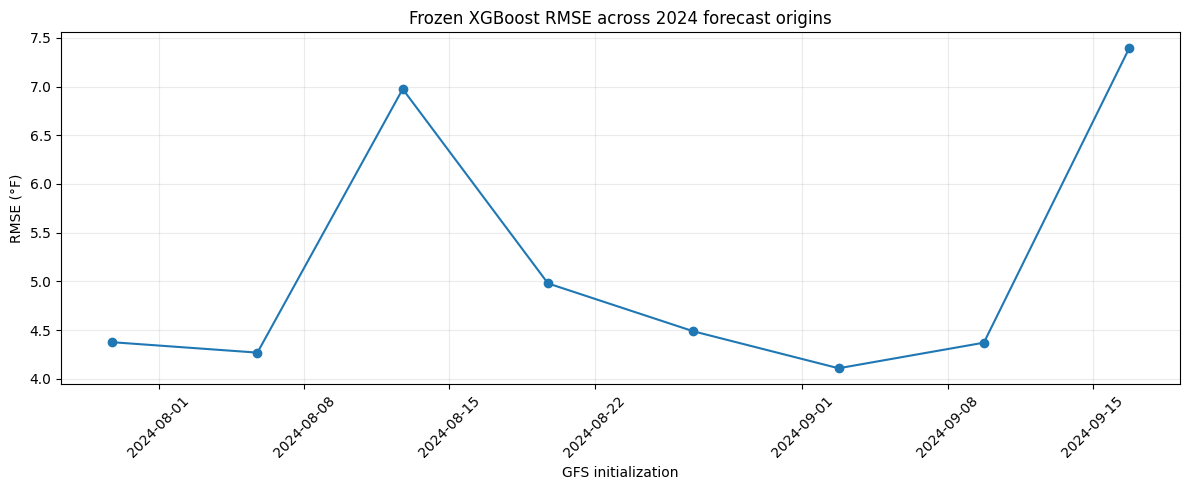

In [17]:
plt.figure(figsize=(12, 5))

plt.plot(
    validation_run_metrics[
        "gfs_init_utc"
    ],
    validation_run_metrics[
        "RMSE_F"
    ],
    marker="o",
)

plt.title(
    "Frozen XGBoost RMSE across 2024 forecast origins"
)
plt.xlabel("GFS initialization")
plt.ylabel("RMSE (°F)")
plt.xticks(rotation=45)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

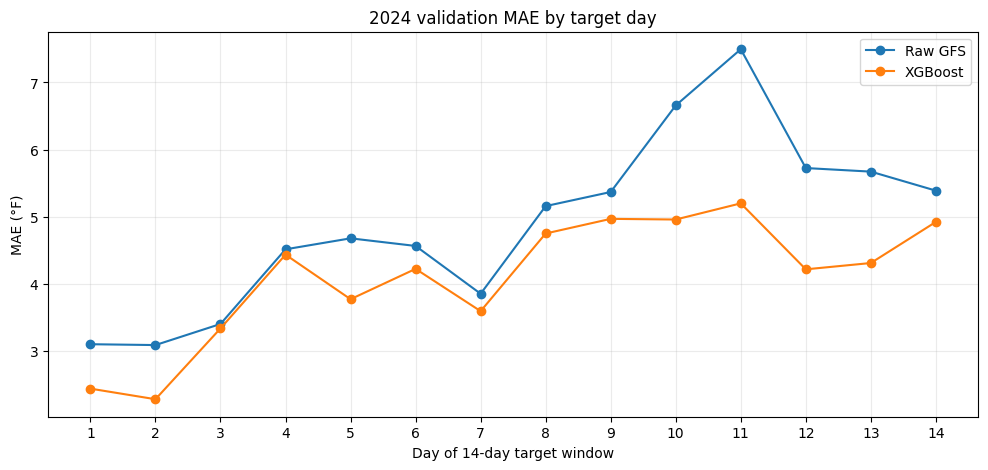

In [18]:
xgb_day_mae = (
    validation_predictions
    .groupby("target_day")
    ["xgb_abs_error_f"]
    .mean()
)

raw_day_mae = (
    validation_predictions
    .assign(
        raw_abs_error_f=lambda d: (
            d["gfs_temp_f"]
            - d[TARGET]
        ).abs()
    )
    .groupby("target_day")
    ["raw_abs_error_f"]
    .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    raw_day_mae.index,
    raw_day_mae.values,
    marker="o",
    label="Raw GFS",
)

plt.plot(
    xgb_day_mae.index,
    xgb_day_mae.values,
    marker="o",
    label="XGBoost",
)

plt.title(
    "2024 validation MAE by target day"
)
plt.xlabel("Day of 14-day target window")
plt.ylabel("MAE (°F)")
plt.xticks(range(1, 15))
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 11. Feature importance on the frozen validation model

XGBoost's gain importance shows which variables contributed most to tree splits.

This is useful for understanding the fitted model, but it is **not causal evidence** and should not be interpreted as proving that a weather variable causes forecast error.

In [19]:
booster = frozen_validation_model.get_booster()

gain_scores = booster.get_score(
    importance_type="gain"
)

# XGBoost usually reports keys as feature names when trained on DataFrames.
feature_importance = pd.DataFrame({
    "feature": FINAL_FEATURES,
})

feature_importance[
    "gain"
] = feature_importance[
    "feature"
].map(gain_scores).fillna(0.0)

gain_total = feature_importance[
    "gain"
].sum()

if gain_total > 0:
    feature_importance[
        "gain_fraction"
    ] = (
        feature_importance["gain"]
        / gain_total
    )
else:
    feature_importance[
        "gain_fraction"
    ] = 0.0

feature_importance = (
    feature_importance
    .sort_values(
        "gain",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    feature_importance.head(20).round(5)
)

,feature,gain,gain_fraction
0,gfs_temp_f,2088.38940,0.15446
1,hour_cos,1559.37830,0.11533
2,gfs_temp_minus_recent_actual_f,1349.59021,0.09982
3,gfs_dewpoint_depression_f,1192.70630,0.08821
4,gfs_precip_rate_mm_hr,770.70953,0.05700
5,doy_sin,661.54376,0.04893
6,forecast_hour,654.36993,0.04840
7,recent_actual_temp_f,574.32965,0.04248
8,gfs_v10_mps,569.26184,0.04210
9,doy_cos,501.40833,0.03708


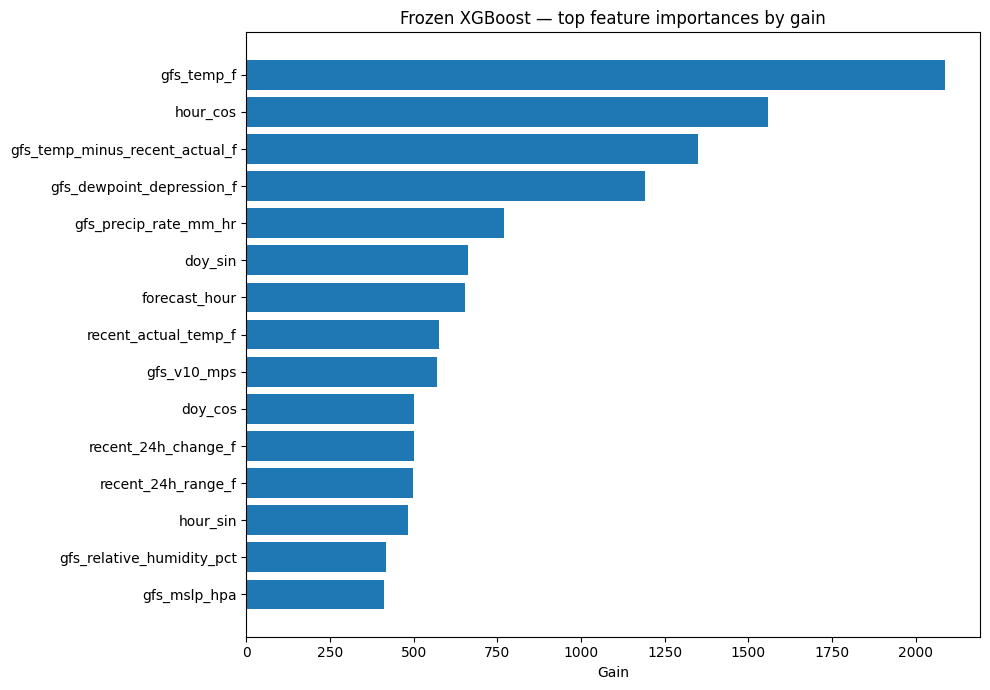

In [20]:
plt.figure(figsize=(10, 7))

top_importance = (
    feature_importance
    .head(15)
    .sort_values("gain")
)

plt.barh(
    top_importance["feature"],
    top_importance["gain"],
)

plt.title(
    "Frozen XGBoost — top feature importances by gain"
)
plt.xlabel("Gain")
plt.tight_layout()
plt.show()

# 12. Unlock the 2025 historical test set

The XGBoost specification is now frozen.

We fit that frozen specification on all **2021–2024** development data and evaluate it exactly once on 2025.

In [21]:
development = historical[
    historical["split"].isin(
        [
            "train",
            "validation",
        ]
    )
].copy()

frozen_model_for_test = fit_xgb(
    train_frame=development,
    features=FINAL_FEATURES,
    spec=FINAL_SPEC,
)

test_predictions = test.copy()

test_predictions[
    "pred_raw_gfs"
] = test_predictions[
    "gfs_temp_f"
]

test_predictions[
    "pred_xgboost"
] = predictions_from_model(
    model=frozen_model_for_test,
    frame=test_predictions,
    features=FINAL_FEATURES,
    target_mode=FINAL_SPEC[
        "target_mode"
    ],
)

raw_test_summary = summarize_model(
    test_predictions,
    "pred_raw_gfs",
)

xgb_test_summary = summarize_model(
    test_predictions,
    "pred_xgboost",
)

test_comparison_rows = [
    {
        "model": "Raw_GFS",
        **raw_test_summary,
    },
    {
        "model": (
            "XGBoost__"
            + FINAL_CANDIDATE_NAME
        ),
        **xgb_test_summary,
    },
]

In [22]:
if LINEAR_TEST_PATH.exists():
    linear_test = pd.read_csv(
        LINEAR_TEST_PATH
    )

    linear_candidates = linear_test[
        linear_test["model"] != "Raw_GFS"
    ].copy()

    if len(linear_candidates):
        best_linear_test = (
            linear_candidates
            .sort_values("RMSE_F")
            .iloc[0]
        )

        test_comparison_rows.append({
            "model": (
                "Linear__"
                + str(
                    best_linear_test[
                        "model"
                    ]
                )
            ),
            "n": best_linear_test["n"],
            "RMSE_F": best_linear_test[
                "RMSE_F"
            ],
            "MAE_F": best_linear_test[
                "MAE_F"
            ],
            "Bias_F": best_linear_test[
                "Bias_F"
            ],
            "R2": best_linear_test["R2"],
            "mean_run_RMSE_F": (
                best_linear_test[
                    "mean_run_RMSE_F"
                ]
            ),
            "median_run_RMSE_F": (
                best_linear_test[
                    "median_run_RMSE_F"
                ]
            ),
            "worst_run_RMSE_F": (
                best_linear_test[
                    "worst_run_RMSE_F"
                ]
            ),
        })


test_comparison = (
    pd.DataFrame(
        test_comparison_rows
    )
    .sort_values("RMSE_F")
    .reset_index(drop=True)
)

display(
    test_comparison.round(4)
)

,model,n,RMSE_F,MAE_F,Bias_F,R2,mean_run_RMSE_F,median_run_RMSE_F,worst_run_RMSE_F
0,XGBoost__residual__compact_residual__medium_re...,2485.0,5.5839,4.1928,2.9631,0.4719,5.4165,5.0939,7.8270
1,Linear__OLS_GFS_only,2485.0,6.0485,4.6138,3.2215,0.3803,5.9291,6.0816,8.3204
2,Raw_GFS,2485.0,6.5187,4.8107,2.2724,0.2802,6.3830,6.4596,8.5049


In [23]:
TEST_RESULTS_PATH = (
    PROCESSED_DIR
    / "xgboost_test_results.csv"
)

test_comparison.to_csv(
    TEST_RESULTS_PATH,
    index=False,
)

TEST_PREDICTIONS_PATH = (
    PROCESSED_DIR
    / "xgboost_2025_test_predictions.csv"
)

test_predictions[
    [
        "gfs_init_utc",
        "valid_time_utc",
        "valid_time_local",
        "forecast_hour",
        "target_day",
        TARGET,
        "pred_raw_gfs",
        "pred_xgboost",
    ]
].to_csv(
    TEST_PREDICTIONS_PATH,
    index=False,
)

print("Saved:", TEST_RESULTS_PATH)
print("Saved:", TEST_PREDICTIONS_PATH)

Saved: /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/data/processed/xgboost_test_results.csv
Saved: /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/data/processed/xgboost_2025_test_predictions.csv


## 13. 2025 test diagnostics

We do not retune after seeing these results.

The key questions are:

1. Does XGBoost beat raw GFS?
2. Does XGBoost beat the frozen linear regression?
3. Does it improve both RMSE and MAE?
4. Does it reduce or worsen systematic bias?
5. Is the improvement consistent across forecast origins and forecast horizons?

In [24]:
test_predictions[
    "xgb_error_f"
] = (
    test_predictions[
        "pred_xgboost"
    ]
    - test_predictions[TARGET]
)

test_predictions[
    "xgb_abs_error_f"
] = test_predictions[
    "xgb_error_f"
].abs()

test_run_metrics = per_run_metrics(
    test_predictions,
    "pred_xgboost",
)

display(
    test_run_metrics.round(3)
)

,gfs_init_utc,n,RMSE_F,MAE_F,Bias_F,R2
0,2025-07-29 18:00:00+00:00,336,7.827,6.178,5.779,-0.469
1,2025-08-05 18:00:00+00:00,336,4.008,3.096,2.193,0.541
2,2025-08-12 18:00:00+00:00,336,3.665,2.752,1.253,0.607
3,2025-08-19 18:00:00+00:00,243,4.340,3.344,3.016,0.630
4,2025-08-26 18:00:00+00:00,238,6.904,5.089,4.600,0.449
5,2025-09-02 18:00:00+00:00,328,6.399,4.896,3.716,0.370
6,2025-09-09 18:00:00+00:00,333,5.779,4.918,3.769,0.444
7,2025-09-16 18:00:00+00:00,335,4.409,3.316,-0.113,0.683


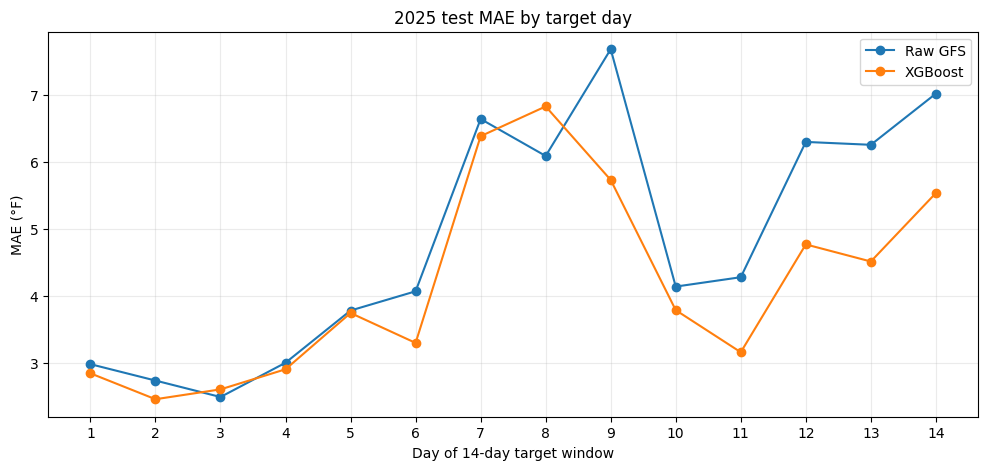

In [25]:
xgb_test_day_mae = (
    test_predictions
    .groupby("target_day")
    ["xgb_abs_error_f"]
    .mean()
)

raw_test_day_mae = (
    test_predictions
    .assign(
        raw_abs_error_f=lambda d: (
            d["gfs_temp_f"]
            - d[TARGET]
        ).abs()
    )
    .groupby("target_day")
    ["raw_abs_error_f"]
    .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    raw_test_day_mae.index,
    raw_test_day_mae.values,
    marker="o",
    label="Raw GFS",
)

plt.plot(
    xgb_test_day_mae.index,
    xgb_test_day_mae.values,
    marker="o",
    label="XGBoost",
)

plt.title(
    "2025 test MAE by target day"
)
plt.xlabel("Day of 14-day target window")
plt.ylabel("MAE (°F)")
plt.xticks(range(1, 15))
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 14. Refit frozen XGBoost on all 2021–2025 labeled data

After 2025 has been used once as the historical test, all 2021–2025 rows are legitimate training data for the actual 2026 forecast.

The model specification remains frozen; we only re-estimate its trees using all eligible historical labels.

In [26]:
final_training_data = historical.copy()

final_model = fit_xgb(
    train_frame=final_training_data,
    features=FINAL_FEATURES,
    spec=FINAL_SPEC,
)

future_predictions = future.copy()

future_predictions[
    "xgboost_temp_f"
] = predictions_from_model(
    model=final_model,
    frame=future_predictions,
    features=FINAL_FEATURES,
    target_mode=FINAL_SPEC[
        "target_mode"
    ],
)

future_predictions[
    "raw_gfs_temp_f"
] = future_predictions[
    "gfs_temp_f"
]

future_predictions[
    "xgboost_minus_raw_gfs_f"
] = (
    future_predictions[
        "xgboost_temp_f"
    ]
    - future_predictions[
        "raw_gfs_temp_f"
    ]
)

assert len(future_predictions) == 336

display(
    future_predictions[
        [
            "valid_time_local",
            "forecast_hour",
            "raw_gfs_temp_f",
            "xgboost_temp_f",
            "xgboost_minus_raw_gfs_f",
        ]
    ].head(24)
)

,valid_time_local,forecast_hour,raw_gfs_temp_f,xgboost_temp_f,xgboost_minus_raw_gfs_f
0,2026-09-17 00:00:00-04:00,10,69.350,69.174776,-0.175224
1,2026-09-17 01:00:00-04:00,11,68.900,68.939015,0.039015
2,2026-09-17 02:00:00-04:00,12,67.325,67.710638,0.385638
3,2026-09-17 03:00:00-04:00,13,66.650,66.961513,0.311513
4,2026-09-17 04:00:00-04:00,14,65.750,66.156447,0.406447
5,2026-09-17 05:00:00-04:00,15,65.075,65.418368,0.343368
6,2026-09-17 06:00:00-04:00,16,64.400,64.787713,0.387713
7,2026-09-17 07:00:00-04:00,17,64.175,66.803672,2.628672
8,2026-09-17 08:00:00-04:00,18,67.550,71.643032,4.093032
9,2026-09-17 09:00:00-04:00,19,72.725,76.752734,4.027734


## 15. Optionally compare 2026 XGBoost with the frozen linear forecast

In [27]:
if LINEAR_2026_PATH.exists():
    linear_2026 = pd.read_csv(
        LINEAR_2026_PATH,
        parse_dates=[
            "valid_time_utc",
        ],
    )

    linear_merge_columns = [
        "valid_time_utc",
        "linear_regression_temp_f",
    ]

    future_predictions = (
        future_predictions
        .merge(
            linear_2026[
                linear_merge_columns
            ],
            on="valid_time_utc",
            how="left",
            validate="one_to_one",
        )
    )

    future_predictions[
        "xgboost_minus_linear_f"
    ] = (
        future_predictions[
            "xgboost_temp_f"
        ]
        - future_predictions[
            "linear_regression_temp_f"
        ]
    )

    print(
        "Mean XGBoost - Linear adjustment:",
        future_predictions[
            "xgboost_minus_linear_f"
        ].mean(),
        "°F",
    )

    print(
        "Largest |XGBoost - Linear| difference:",
        future_predictions[
            "xgboost_minus_linear_f"
        ].abs().max(),
        "°F",
    )
else:
    print(
        "Linear 2026 prediction file not found. "
        "Skipping direct 2026 model comparison."
    )

Mean XGBoost - Linear adjustment: -0.017772323015684405 °F
Largest |XGBoost - Linear| difference: 7.517769696851417 °F


## 16. Sanity-check the 2026 forecast

In [28]:
summary_columns = [
    "raw_gfs_temp_f",
    "xgboost_temp_f",
    "xgboost_minus_raw_gfs_f",
]

if "linear_regression_temp_f" in future_predictions.columns:
    summary_columns.append(
        "linear_regression_temp_f"
    )

display(
    future_predictions[
        summary_columns
    ].describe().T.round(3)
)

print(
    "Largest absolute XGBoost adjustment vs raw GFS:",
    future_predictions[
        "xgboost_minus_raw_gfs_f"
    ].abs().max(),
    "°F",
)

print(
    "Mean XGBoost adjustment vs raw GFS:",
    future_predictions[
        "xgboost_minus_raw_gfs_f"
    ].mean(),
    "°F",
)

,count,mean,std,min,25%,50%,75%,max
raw_gfs_temp_f,336.0,70.753,7.773,55.512,65.075,70.025,74.338,95.450
xgboost_temp_f,336.0,72.507,7.055,58.674,67.050,72.163,77.271,92.073
xgboost_minus_raw_gfs_f,336.0,1.754,3.091,-4.652,-0.586,1.824,3.924,10.500
linear_regression_temp_f,336.0,72.525,5.346,62.043,68.620,72.024,74.990,89.510


Largest absolute XGBoost adjustment vs raw GFS: 10.50036334991455 °F
Mean XGBoost adjustment vs raw GFS: 1.7538733348871272 °F


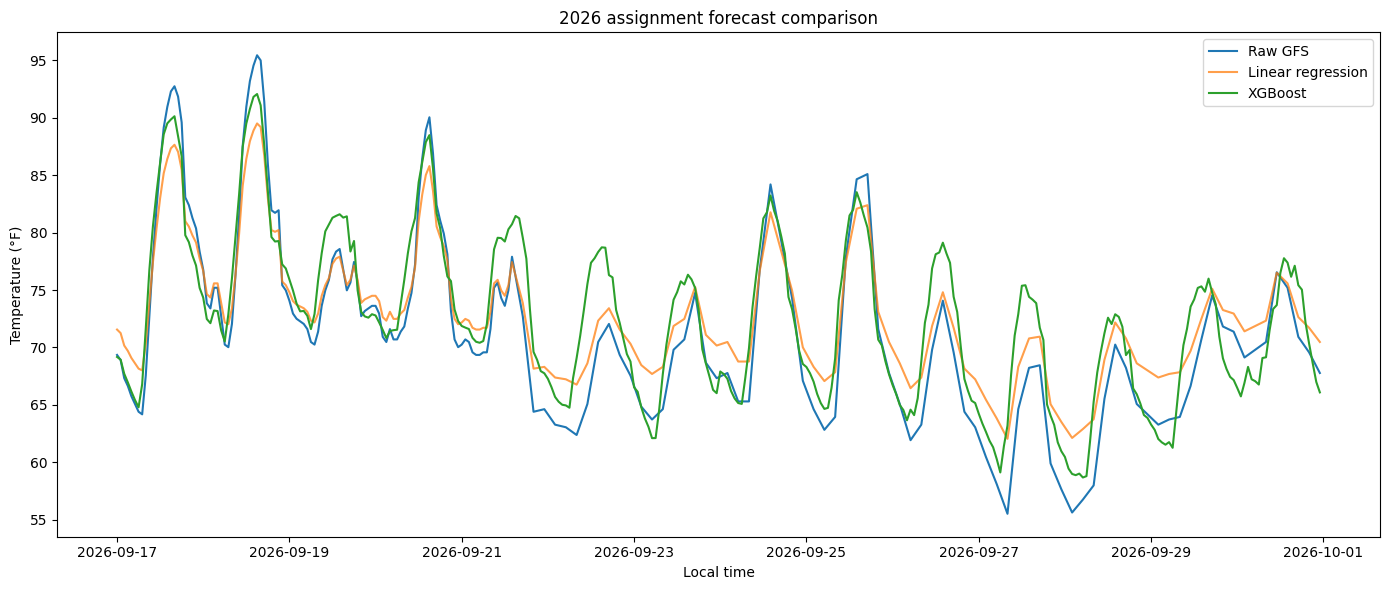

In [29]:
plt.figure(figsize=(14, 6))

plt.plot(
    future_predictions[
        "valid_time_local"
    ],
    future_predictions[
        "raw_gfs_temp_f"
    ],
    label="Raw GFS",
)

if (
    "linear_regression_temp_f"
    in future_predictions.columns
):
    plt.plot(
        future_predictions[
            "valid_time_local"
        ],
        future_predictions[
            "linear_regression_temp_f"
        ],
        alpha=0.75,
        label="Linear regression",
    )

plt.plot(
    future_predictions[
        "valid_time_local"
    ],
    future_predictions[
        "xgboost_temp_f"
    ],
    label="XGBoost",
)

plt.title(
    "2026 assignment forecast comparison"
)
plt.xlabel("Local time")
plt.ylabel("Temperature (°F)")
plt.legend()
plt.tight_layout()
plt.show()

## 17. Save final 2026 predictions

In [30]:
PREDICTIONS_OUTPUT = (
    PROCESSED_DIR
    / "xgboost_2026_predictions.csv"
)

prediction_columns = [
    "valid_time_utc",
    "valid_time_local",
    "forecast_hour",
    "target_day",
    "local_hour",
    "raw_gfs_temp_f",
]

if (
    "linear_regression_temp_f"
    in future_predictions.columns
):
    prediction_columns.append(
        "linear_regression_temp_f"
    )

prediction_columns.extend([
    "xgboost_temp_f",
    "xgboost_minus_raw_gfs_f",
])

if (
    "xgboost_minus_linear_f"
    in future_predictions.columns
):
    prediction_columns.append(
        "xgboost_minus_linear_f"
    )

prediction_output = future_predictions[
    prediction_columns
].copy()

prediction_output.to_csv(
    PREDICTIONS_OUTPUT,
    index=False,
)

print("Saved:", PREDICTIONS_OUTPUT)
print("Rows:", len(prediction_output))

display(
    prediction_output.head()
)

display(
    prediction_output.tail()
)

Saved: /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/data/processed/xgboost_2026_predictions.csv
Rows: 336


,valid_time_utc,valid_time_local,forecast_hour,target_day,local_hour,raw_gfs_temp_f,linear_regression_temp_f,xgboost_temp_f,xgboost_minus_raw_gfs_f,xgboost_minus_linear_f
0,2026-09-17 04:00:00+00:00,2026-09-17 00:00:00-04:00,10,1,0,69.350,71.559795,69.174776,-0.175224,-2.385019
1,2026-09-17 05:00:00+00:00,2026-09-17 01:00:00-04:00,11,1,1,68.900,71.250304,68.939015,0.039015,-2.311288
2,2026-09-17 06:00:00+00:00,2026-09-17 02:00:00-04:00,12,1,2,67.325,70.167085,67.710638,0.385638,-2.456447
3,2026-09-17 07:00:00+00:00,2026-09-17 03:00:00-04:00,13,1,3,66.650,69.702848,66.961513,0.311513,-2.741335
4,2026-09-17 08:00:00+00:00,2026-09-17 04:00:00-04:00,14,1,4,65.750,69.083866,66.156447,0.406447,-2.927419


,valid_time_utc,valid_time_local,forecast_hour,target_day,local_hour,raw_gfs_temp_f,linear_regression_temp_f,xgboost_temp_f,xgboost_minus_raw_gfs_f,xgboost_minus_linear_f
331,2026-09-30 23:00:00+00:00,2026-09-30 19:00:00-04:00,341,14,19,70.025,72.024032,72.173730,2.148730,0.149698
332,2026-10-01 00:00:00+00:00,2026-09-30 20:00:00-04:00,342,14,20,69.575,71.714541,70.343595,0.768595,-1.370945
333,2026-10-01 01:00:00+00:00,2026-09-30 21:00:00-04:00,343,14,21,68.975,71.301886,68.638680,-0.336320,-2.663206
334,2026-10-01 02:00:00+00:00,2026-09-30 22:00:00-04:00,344,14,22,68.375,70.889231,67.000673,-1.374327,-3.888558
335,2026-10-01 03:00:00+00:00,2026-09-30 23:00:00-04:00,345,14,23,67.775,70.476576,66.087215,-1.687785,-4.389361


## 18. Save final feature importance

In [31]:
final_booster = final_model.get_booster()

final_gain_scores = (
    final_booster.get_score(
        importance_type="gain"
    )
)

final_feature_importance = pd.DataFrame({
    "feature": FINAL_FEATURES,
})

final_feature_importance[
    "gain"
] = final_feature_importance[
    "feature"
].map(
    final_gain_scores
).fillna(0.0)

gain_total = final_feature_importance[
    "gain"
].sum()

if gain_total > 0:
    final_feature_importance[
        "gain_fraction"
    ] = (
        final_feature_importance[
            "gain"
        ]
        / gain_total
    )
else:
    final_feature_importance[
        "gain_fraction"
    ] = 0.0

final_feature_importance = (
    final_feature_importance
    .sort_values(
        "gain",
        ascending=False,
    )
    .reset_index(drop=True)
)

FEATURE_IMPORTANCE_PATH = (
    PROCESSED_DIR
    / "xgboost_feature_importance.csv"
)

final_feature_importance.to_csv(
    FEATURE_IMPORTANCE_PATH,
    index=False,
)

print(
    "Saved:",
    FEATURE_IMPORTANCE_PATH,
)

display(
    final_feature_importance.head(20).round(5)
)

Saved: /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/data/processed/xgboost_feature_importance.csv


,feature,gain,gain_fraction
0,gfs_temp_f,3829.42749,0.16938
1,gfs_temp_minus_recent_actual_f,2878.10645,0.12730
2,hour_cos,2426.77368,0.10734
3,gfs_dewpoint_depression_f,2109.47241,0.09330
4,gfs_precip_rate_mm_hr,1221.69849,0.05404
5,target_day,1025.23657,0.04535
6,forecast_hour,1020.51642,0.04514
7,gfs_relative_humidity_pct,913.48621,0.04040
8,recent_24h_mean_f,794.84979,0.03516
9,hour_sin,788.30579,0.03487


## 19. Final summary

In [32]:
summary_rows = [
    {
        "stage": "2024 validation",
        "model": "Raw GFS",
        "RMSE_F": raw_validation_summary[
            "RMSE_F"
        ],
        "MAE_F": raw_validation_summary[
            "MAE_F"
        ],
        "Bias_F": raw_validation_summary[
            "Bias_F"
        ],
    },
    {
        "stage": "2024 validation",
        "model": "XGBoost",
        "RMSE_F": WINNER["RMSE_F"],
        "MAE_F": WINNER["MAE_F"],
        "Bias_F": WINNER["Bias_F"],
    },
    {
        "stage": "2025 test",
        "model": "Raw GFS",
        "RMSE_F": raw_test_summary[
            "RMSE_F"
        ],
        "MAE_F": raw_test_summary[
            "MAE_F"
        ],
        "Bias_F": raw_test_summary[
            "Bias_F"
        ],
    },
    {
        "stage": "2025 test",
        "model": "XGBoost",
        "RMSE_F": xgb_test_summary[
            "RMSE_F"
        ],
        "MAE_F": xgb_test_summary[
            "MAE_F"
        ],
        "Bias_F": xgb_test_summary[
            "Bias_F"
        ],
    },
]

final_summary = pd.DataFrame(
    summary_rows
)

display(
    final_summary.round(4)
)

print(
    "\nFrozen XGBoost candidate:",
    FINAL_CANDIDATE_NAME,
)

print(
    "Final feature count:",
    len(FINAL_FEATURES),
)

print(
    "2026 prediction rows:",
    len(prediction_output),
)

print(
    "\nXGBoost workflow complete. "
    "Do not retune this model based on 2025. "
    "The next decision should compare the frozen linear and XGBoost "
    "models and decide whether a validation-justified blend is worth testing."
)

,stage,model,RMSE_F,MAE_F,Bias_F
0,2024 validation,Raw GFS,6.3628,4.9068,-1.4968
1,2024 validation,XGBoost,5.2623,4.1035,-0.1865
2,2025 test,Raw GFS,6.5187,4.8107,2.2724
3,2025 test,XGBoost,5.5839,4.1928,2.9631



Frozen XGBoost candidate: residual__compact_residual__medium_regularized
Final feature count: 19
2026 prediction rows: 336

XGBoost workflow complete. Do not retune this model based on 2025. The next decision should compare the frozen linear and XGBoost models and decide whether a validation-justified blend is worth testing.
